# Lab - YOLOv4-Tiny Part 5 - PyTorch Inference Optimization 

## E6792 Spring 2026

In this notebook you will measure the throughput of your custom trained YOLOv4-Tiny model.

In [1]:
import torch # import modules
import sys
import time
import numpy as np
import time

from darknet_utils.darknet_to_pytorch import load_pytorch # import custom modules
from darknet_utils.inference import measure_throughput, plot_execution_times

cfg_path = 'cfg/yolov4-tiny-person-vehicle.cfg' # path to configuration file of custom model

torch_weights_path = 'weights/yolov4-tiny-person-vehicle_best.pt' # path to JIT optimized model

device = 'cuda'

%load_ext autoreload
%autoreload 2

<font color="red"><strong>TODO:</strong></font>  Load the custom trained YOLOv4-Tiny PyTorch model in the cell below. 

**TIP**: If you don't want to see the model summary, you can insert `%%capture` as the first line in the cell to hide all output.

In [2]:
###################################################
# TODO: Load the custom trained YOLOv4-Tiny with  #
#       load_pytorch()                            #
###################################################


pytorch_model = load_pytorch(cfg_path, torch_weights_path)
pytorch_model = pytorch_model.to(device)
pytorch_model.eval()

###################################################
# END TODO                                        #
###################################################

Darknet(
  (models): ModuleList(
    (0): Sequential(
      (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (leaky1): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (1): Sequential(
      (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (leaky2): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (2): Sequential(
      (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (leaky3): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (3): EmptyModule()
    (4): Sequential(
      (conv4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn4):

### Define throughput in the context of deep learning models.

<font color="red"><strong>TODO:</strong></font> Throughput refers to the number of inputs that a model can process within each unit of time. Within the scope of deep learning, it is generally expressed in terms of frames per second, which means the number of images that can be processed per second. The higher the throughput, the faster the model's inference speed, and thus it is more suitable for real-time applications.

<font color="red"><strong>TODO:</strong></font>  Complete the function **measure_throughput()** in **darknet_utils/inference.py**.

In [3]:
###################################################
# TODO: Use measure_throughput() to measure the   #
#       throughput of your PyTorch YOLOv4-Tiny    #
#                                                 #
#       What is a reasonable input shape to       #
#       measure throughput?                       #
###################################################

# because My YOLOv4-Tiny model was trained using an resolution of 416×416, So here I define this way

input_shape = (1, 3, 416, 416)

throughput = measure_throughput(
    pytorch_model,
    input_shape=input_shape,
    warmup_iterations=50,
    iterations=200
)

###################################################
# END TODO                                        #
###################################################

Average time: 0.005504605770111084
Throughput: 181.66605235016127


Now you will investigate the PyTorch [JIT](https://en.wikipedia.org/wiki/Just-in-time_compilation) functionality to further optimize YOLOv4-Tiny for inference on the Jetson Nano. [PyTorch JIT](https://pytorch.org/docs/stable/jit.html) has two methods for converting a standard PyTorch model to a [TorchScript](https://pytorch.org/docs/stable/jit.html#:~:text=TorchScript%20is%20a%20way%20to,there%20is%20no%20Python%20dependency.) model - script and trace. Torchscript models are optimizable and serializable. That means they can be saved independently from Python and used in other contexts like a C++ program. 

### What is meant by eager execution and graph execution?


<font color="red"><strong>TODO:</strong></font>  "Eager execution" means that the operations within the model will be executed immediately when they are called. Each operation runs step by step in Python. It is roughly similar to the pattern where I execute a small piece of code immediately after writing it, and it is suitable for debugging. 

Graph execution first builds a static computational graph, and then executes it. This method analyzes and optimizes the graph before running it, because the entire computational structure can be understood before the execution.

### Explain the difference between "script" and "trace". When would you use jit.script and when would you use jit.trace? Why do you need to include a sample input when using jit.trace?


<font color="red"><strong>TODO:</strong></font>  

#### difference between "script" and "trace ####
jit.script is used for parsing Python code. It can convert PyTorch models into TorchScript format by directly analyzing the source code of the model. It can understand control flow elements such as loops, conditional statements, and dynamic behaviors. jit.script is suitable for models with dynamic control flow. 

jit.trace generates the computational graph solely based on the operations observed during the execution process. It is unable to capture the dynamic control flow that depends on the input values. 

When you call torch.jit.trace(model, example_inputs), PyTorch runs the model's forward method with the provided example_inputs. As each operation executes, PyTorch logs it. The resulting ScriptModule essentially contains a frozen snapshot of the computation graph generated during that single forward pass.



#### When would you use jit.script and when would you use jit.trace? ####

jit.script is used when a model contains dynamic control flow


jit.trace is used when the model has a static computation graph and does not rely on input-dependent control flow.


#### Why do you need to include a sample input when using jit.trace? ####
Because the tracer needs to run the model once to observe and record the sequence of operations in order to construct the computation graph.

<font color="red"><strong>TODO:</strong></font>  Use `torch.jit.trace()` to create a traced TorchScript model. Save the traced model weights to the weights directory with `torch.jit.save()`.

In [6]:
####################################################
# TODO: Use torch.jit to generate a traced PyTorch #
#       to generate a sawtooth mask                #
####################################################
with torch.no_grad():
    traced_model = torch.jit.trace(pytorch_model, torch.randn(input_shape).to(device))

traced_model.save('weights/yolov4-tiny-person-vehicle_traced.pt')

####################################################
# END TODO                                         #
####################################################

In [5]:
# Verify that output of traced model matches output of original model

input_array = torch.randn((4, 3, 416, 416)).to(device) # define input tensor

torch_output = pytorch_model(input_array)[0].cpu().detach().numpy() # pass input through models
jit_output = traced_model(input_array)[0].cpu().detach().numpy()

print("JIT traced model matches PyTorch: ", np.allclose(torch_output, jit_output)) # compare outputs

JIT traced model matches PyTorch:  True


In [7]:
####################################################
# TODO: Use measure_throughput() to measure the    #
#       throughput of your traced YOLOv4-Tiny      #
####################################################
traced_model = traced_model.to(device)
traced_model.eval()

jit_throughput = measure_throughput(
    traced_model,
    input_shape=input_shape,
    warmup_iterations=50,
    iterations=200,
    verbose=True
)

####################################################
# END TODO                                         #
####################################################

Average time: 0.0026140403747558594
Throughput: 382.5495618419421


<font color="red"><strong>TODO:</strong></font>  Calculate and plot throughput as a function of batch size for both models on GCP and Jetson Nano. Calculate throughput for the largest batch size you can fit into the Jetson Nano's memory. You're welcome to use **plot_execution_times()** or your own plotting function.

In [9]:
####################################################
# TODO: Calculate throughput as a function of      #
#       batch size for both models (GCP)                #
####################################################
def measure_throughput_batch(model, batch_sizes, device,
                             warmup_iterations=20, iterations=100):
    
    throughputs = []

    for bs in batch_sizes:
        input_shape = (bs, 3, 416, 416)

        print(f"Measuring throughput for batch size = {bs}")

        t = measure_throughput(
            model,
            input_shape=input_shape,
            warmup_iterations=warmup_iterations,
            iterations=iterations,
            verbose=True
        )

        throughputs.append(t)

    return throughputs


batch_sizes = [1, 2, 4, 8, 16]

throughput_torch_gcp = measure_throughput_batch(
    pytorch_model,
    batch_sizes,
    device
)

throughput_jit_gcp = measure_throughput_batch(
    traced_model,
    batch_sizes,
    device
)
    
####################################################
# END TODO                                         #
####################################################

Measuring throughput for batch size = 1
Average time: 0.005761744976043701
Throughput: 173.55853203462146
Measuring throughput for batch size = 2
Average time: 0.006451942920684814
Throughput: 309.984143472199
Measuring throughput for batch size = 4
Average time: 0.0108851957321167
Throughput: 367.47157317511767
Measuring throughput for batch size = 8
Average time: 0.018792362213134767
Throughput: 425.7048639903538
Measuring throughput for batch size = 16
Average time: 0.029354515075683593
Throughput: 545.0609542943506
Measuring throughput for batch size = 1
Average time: 0.002720069885253906
Throughput: 367.6376130706122
Measuring throughput for batch size = 2
Average time: 0.004734923839569092
Throughput: 422.3932776460482
Measuring throughput for batch size = 4
Average time: 0.00946925401687622
Throughput: 422.41975902971353
Measuring throughput for batch size = 8
Average time: 0.01747364044189453
Throughput: 457.83247209432807
Measuring throughput for batch size = 16
Average time: 

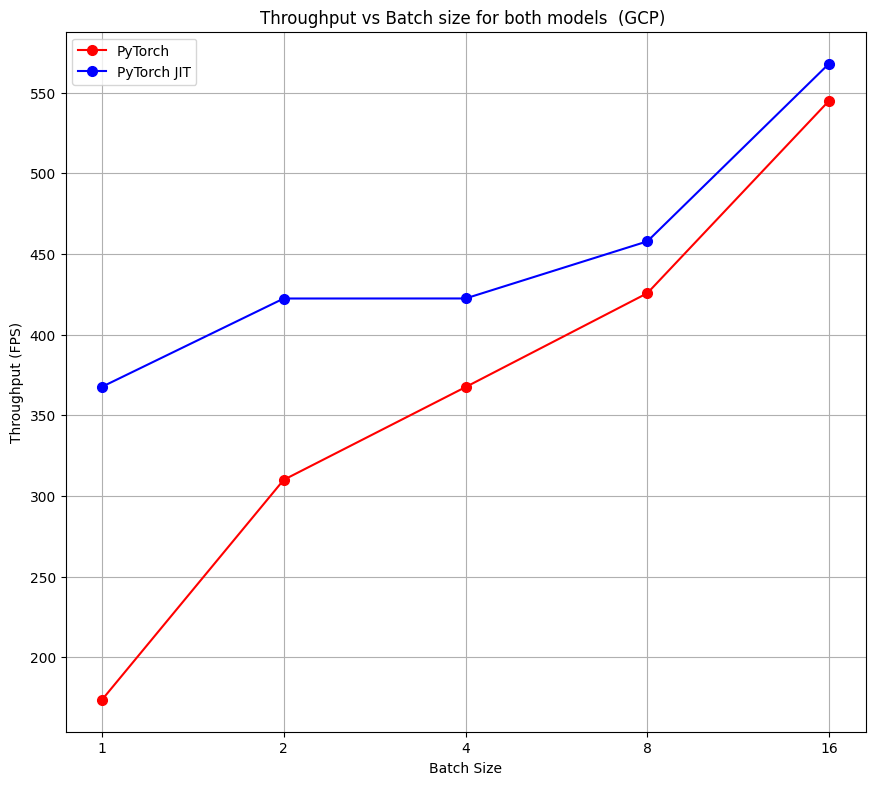

In [10]:
####################################################
# TODO: Plot throughput as a function of batch     #
#       size for both models  (GCP)                    #
####################################################

plot_execution_times(
    throughput_torch=throughput_torch_gcp,
    throughput_jit=throughput_jit_gcp,
    title="Throughput vs Batch size for both models  (GCP) ",
    batch_sizes=batch_sizes,
    logy=False
)

####################################################
# END TODO                                         #
####################################################

In [ ]:
####################################################
# TODO: Calculate throughput as a function of      #
#       batch size for both models (Jetson)                #
####################################################
def measure_throughput_batch(model, batch_sizes, device,
                             warmup_iterations=20, iterations=100):
    
    throughputs = []

    for bs in batch_sizes:
        input_shape = (bs, 3, 416, 416)

        print(f"Measuring throughput for batch size = {bs}")

        t = measure_throughput(
            model,
            input_shape=input_shape,
            warmup_iterations=warmup_iterations,
            iterations=iterations,
            verbose=True
        )

        throughputs.append(t)

    return throughputs


batch_sizes = [1, 2, 4, 8, 16]

throughput_torch_gcp = measure_throughput_batch(
    pytorch_model,
    batch_sizes,
    device
)

throughput_jit_gcp = measure_throughput_batch(
    traced_model,
    batch_sizes,
    device
)


####################################################
# END TODO                                         #
####################################################

In [ ]:
####################################################
# TODO: Plot throughput as a function of batch     #
#       size for both models  (Jetson)                    #
####################################################
plot_execution_times(
    throughput_torch=throughput_torch_gcp,
    throughput_jit=throughput_jit_gcp,
    title="Throughput vs Batch size for both models  (GCP) ",
    batch_sizes=batch_sizes,
    logy=False
)


####################################################
# END TODO                                         #
####################################################

### Discuss the results of your throughput measurements. Are there any surprising results? Which batch sizes result in the largest throughputs? Is this batch size reasonable to use in real-time applications?


<font color="red"><strong>TODO:</strong></font>  The throughput on Jetson Nano is significantly lower than on GCP due to the more limited computational resources. However, the same trend is observed: throughput increases with batch size and TorchScript consistently outperforms the standard PyTorch model.